# Notebook 04 -- Submission Generation

This notebook generates Kaggle submission files for the March Madness NCAA
basketball prediction competition. It loads the trained models and computes
**rolling window feature snapshots** for each team, then generates predictions
for every possible matchup.

**Inputs** (from `../outputs/`):
- `m_model_final.joblib` -- trained model for men's tournament
- `w_model_final.joblib` -- trained model for women's tournament
- `feature_columns.json` -- feature column names and metadata
- `m_team_stats.csv` -- men's season-level stats (for static features)
- `w_team_stats.csv` -- women's season-level stats (for static features)

**Outputs** (to `../outputs/`):
- `submission_stage1.csv` -- predictions for Stage 1 (validation, seasons 2022-2025)
- `submission_stage2.csv` -- predictions for Stage 2 (2026 tournament)

## 1. Setup

In [1]:
import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to sys.path so src modules are importable
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import (
    load_sample_submission,
    load_seeds,
    load_regular_season_results,
    load_tourney_results,
)
from src.features import get_team_rolling_snapshot
from src.model import EnsemblePredictor  # needed for joblib to deserialize ensemble

# Plotting configuration
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
})
sns.set_style("whitegrid")

OUTPUT_DIR = PROJECT_ROOT / "outputs"
print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUTPUT_DIR}")

Project root : /Users/sidthakur/Github/mm-2026
Output dir   : /Users/sidthakur/Github/mm-2026/outputs


In [2]:
# Load trained models
model_mens = joblib.load(OUTPUT_DIR / "m_model_final.joblib")
model_womens = joblib.load(OUTPUT_DIR / "w_model_final.joblib")

print(f"Men's model   : {type(model_mens).__name__}")
print(f"Women's model : {type(model_womens).__name__}")

Men's model   : EnsemblePredictor
Women's model : EnsemblePredictor


In [3]:
# Load the feature columns used during training (separate for M and W)
with open(OUTPUT_DIR / "feature_columns.json", "r") as f:
    meta = json.load(f)

m_feature_columns = meta["m_feature_columns"]
w_feature_columns = meta["w_feature_columns"]

print(f"Men's features:   {len(m_feature_columns)} columns")
print(f"Women's features: {len(w_feature_columns)} columns")
print(f"\nMen's: {m_feature_columns}")
print(f"Women's: {w_feature_columns}")

Men's features:   24 columns
Women's features: 20 columns

Men's: ['Win_roll5', 'ts_pct_roll5', 'to_rate_roll5', 'ast_to_ratio_roll5', 'off_reb_pct_roll5', 'def_reb_pct_roll5', 'game_off_eff_roll5', 'game_def_eff_roll5', 'scoring_consistency_roll5', 'OppScore_roll7', 'scoring_consistency_roll7', 'PointDiff_roll10', 'Score_roll10', 'ts_pct_roll10', 'to_rate_roll10', 'ast_to_ratio_roll10', 'off_reb_pct_roll10', 'def_reb_pct_roll10', 'game_off_eff_roll10', 'game_def_eff_roll10', 'scoring_consistency_roll10', 'static_sos', 'static_win_pct', 'static_kenpom_rank']
Women's: ['static_win_pct', 'PointDiff_roll10', 'game_off_eff_roll10', 'Win_roll5', 'game_off_eff_roll5', 'game_def_eff_roll10', 'ts_pct_roll10', 'Score_roll10', 'ast_to_ratio_roll10', 'game_def_eff_roll5', 'ts_pct_roll5', 'OppScore_roll7', 'static_sos', 'ast_to_ratio_roll5', 'to_rate_roll10', 'def_reb_pct_roll10', 'off_reb_pct_roll10', 'off_reb_pct_roll5', 'def_reb_pct_roll5', 'to_rate_roll5']


## 2. Load Team Stats and Compute Rolling Snapshots

For predictions, each team's features come from their **latest rolling window
stats** (last 5/7/10 games before the tournament) plus static season-level
features (SOS, win_pct, efficiency_margin).

In [4]:
%%time
# Load game data for rolling window computation
m_detailed = load_regular_season_results(gender="M", detailed=True)
m_compact = load_regular_season_results(gender="M", detailed=False)
m_tourney_detailed = load_tourney_results(gender="M", detailed=True)
m_tourney_compact = load_tourney_results(gender="M", detailed=False)

w_detailed = load_regular_season_results(gender="W", detailed=True)
w_compact = load_regular_season_results(gender="W", detailed=False)
w_tourney_detailed = load_tourney_results(gender="W", detailed=True)
w_tourney_compact = load_tourney_results(gender="W", detailed=False)

# Combine all games (regular season + tournament)
m_all_detailed = pd.concat([m_detailed, m_tourney_detailed], ignore_index=True)
m_all_compact = pd.concat([m_compact, m_tourney_compact], ignore_index=True)
w_all_detailed = pd.concat([w_detailed, w_tourney_detailed], ignore_index=True)
w_all_compact = pd.concat([w_compact, w_tourney_compact], ignore_index=True)

# Load season-level stats for static features
m_team_stats = pd.read_csv(OUTPUT_DIR / "m_team_stats.csv", index_col=[0, 1])
w_team_stats = pd.read_csv(OUTPUT_DIR / "w_team_stats.csv", index_col=[0, 1])
m_team_stats.index.names = ["Season", "TeamID"]
w_team_stats.index.names = ["Season", "TeamID"]

print(f"Men's all games: {len(m_all_detailed):,}")
print(f"Women's all games: {len(w_all_detailed):,}")
print(f"Men's team stats: {m_team_stats.shape}")
print(f"Women's team stats: {w_team_stats.shape}")

# Compute rolling window snapshots for all needed seasons
# Stage 1 needs 2022-2025, Stage 2 needs 2026
needed_seasons = [2022, 2023, 2024, 2025, 2026]

m_snapshots = {}
w_snapshots = {}

for season in needed_seasons:
    print(f"\nComputing rolling snapshots for season {season}...")
    m_snap = get_team_rolling_snapshot(m_all_detailed, m_all_compact, season=season)
    w_snap = get_team_rolling_snapshot(w_all_detailed, w_all_compact, season=season)
    m_snapshots[season] = m_snap
    w_snapshots[season] = w_snap
    print(f"  Men: {len(m_snap)} teams, Women: {len(w_snap)} teams")

Men's all games: 124,224
Women's all games: 86,466
Men's team stats: (13753, 53)
Women's team stats: (9850, 48)

Computing rolling snapshots for season 2022...


  Men: 358 teams, Women: 356 teams

Computing rolling snapshots for season 2023...


  Men: 363 teams, Women: 361 teams

Computing rolling snapshots for season 2024...


  Men: 362 teams, Women: 360 teams

Computing rolling snapshots for season 2025...


  Men: 364 teams, Women: 362 teams

Computing rolling snapshots for season 2026...


  Men: 365 teams, Women: 363 teams
CPU times: user 18min 57s, sys: 16.9 s, total: 19min 13s
Wall time: 19min 16s


## 3. Parse Submission File

The submission ID format is `SSSS_XXXX_YYYY` where:
- `SSSS` = season year
- `XXXX` = lower TeamID (TeamA)
- `YYYY` = higher TeamID (TeamB)

Men's TeamIDs are in the range 1000-1999, women's in 3000-3999.

In [5]:
def parse_submission(sub_df: pd.DataFrame) -> pd.DataFrame:
    """Parse submission IDs into season, team IDs, and gender columns.
    
    Parameters
    ----------
    sub_df : pd.DataFrame
        Sample submission with an 'ID' column in 'SSSS_XXXX_YYYY' format.
    
    Returns
    -------
    pd.DataFrame
        Copy of sub_df with added columns: Season, TeamA, TeamB, Gender.
    """
    parsed = sub_df.copy()
    
    # Split the ID column into three integer components
    id_parts = parsed["ID"].str.split("_", expand=True).astype(int)
    parsed["Season"] = id_parts[0]
    parsed["TeamA"] = id_parts[1]   # lower ID
    parsed["TeamB"] = id_parts[2]   # higher ID
    
    # Determine gender from TeamA ID range
    # Men's: 1000-1999, Women's: 3000-3999
    parsed["Gender"] = np.where(
        parsed["TeamA"].between(1000, 1999), "M", "W"
    )
    
    return parsed

In [6]:
# Load both stages of the sample submission
# Stage 1: validation on historical seasons (2022-2025)
# Stage 2: predictions for the 2026 tournament
sub_stage1_raw = load_sample_submission(stage=1)
sub_stage2_raw = load_sample_submission(stage=2)

sub_stage1 = parse_submission(sub_stage1_raw)
sub_stage2 = parse_submission(sub_stage2_raw)

print(f"Stage 1 submission rows: {len(sub_stage1):,}")
print(f"  Seasons: {sorted(sub_stage1['Season'].unique())}")
print(f"  Men's matchups: {(sub_stage1['Gender'] == 'M').sum():,}")
print(f"  Women's matchups: {(sub_stage1['Gender'] == 'W').sum():,}")
print()
print(f"Stage 2 submission rows: {len(sub_stage2):,}")
print(f"  Seasons: {sorted(sub_stage2['Season'].unique())}")
print(f"  Men's matchups: {(sub_stage2['Gender'] == 'M').sum():,}")
print(f"  Women's matchups: {(sub_stage2['Gender'] == 'W').sum():,}")

sub_stage1.head()

Stage 1 submission rows: 519,144
  Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Men's matchups: 261,013
  Women's matchups: 258,131

Stage 2 submission rows: 132,133
  Seasons: [np.int64(2026)]
  Men's matchups: 66,430
  Women's matchups: 65,703


,ID,Pred,Season,TeamA,TeamB,Gender
0,2022_1101_1102,0.5,2022,1101,1102,M
1,2022_1101_1103,0.5,2022,1101,1103,M
2,2022_1101_1104,0.5,2022,1101,1104,M
3,2022_1101_1105,0.5,2022,1101,1105,M
4,2022_1101_1106,0.5,2022,1101,1106,M


## 4. Generate Predictions

For each matchup, we:
1. Look up each team's rolling window snapshot (latest N-game stats)
2. Look up each team's static season-level stats (SOS, win_pct, efficiency_margin)
3. Compute feature differences (TeamA - TeamB) for both rolling and static features
4. Use the appropriate model (men's or women's) to predict P(TeamA wins)
5. Handle missing teams by predicting 0.5 (no information = coin flip)

In [7]:
def generate_predictions(
    sub_df: pd.DataFrame,
    m_snapshots: dict,
    w_snapshots: dict,
    m_stats: pd.DataFrame,
    w_stats: pd.DataFrame,
    model_m,
    model_w,
    m_feat_cols: list[str],
    w_feat_cols: list[str],
    m_medians: dict | None = None,
    w_medians: dict | None = None,
) -> pd.DataFrame:
    """Generate predictions using rolling window snapshots + static features.
    
    Parameters
    ----------
    sub_df : pd.DataFrame
        Parsed submission with Season, TeamA, TeamB, Gender columns.
    m_snapshots, w_snapshots : dict[int, pd.DataFrame]
        Rolling snapshots per season, indexed by TeamID.
    m_stats, w_stats : pd.DataFrame
        Season-level stats indexed by (Season, TeamID).
    model_m, model_w : fitted models.
    m_feat_cols, w_feat_cols : feature column lists used during training.
    m_medians, w_medians : dict, optional
        Median fill values for NaN features.
    """
    result = sub_df.copy()
    result["Pred"] = 0.5  # default for missing teams

    # Static features used during training
    static_cols_m = ["sos", "win_pct", "efficiency_margin", "kenpom_rank", "sos_adj_eff_margin"]
    static_cols_w = ["sos", "win_pct", "efficiency_margin", "sos_adj_eff_margin"]

    # NaN fill values for sparse features (must match training)
    nan_fills = {"kenpom_rank": 366}

    for gender, snapshots, stats, model, feat_cols, static_cols, medians in [
        ("M", m_snapshots, m_stats, model_m, m_feat_cols, static_cols_m, m_medians),
        ("W", w_snapshots, w_stats, model_w, w_feat_cols, static_cols_w, w_medians),
    ]:
        mask = result["Gender"] == gender
        if mask.sum() == 0:
            continue

        gender_sub = result.loc[mask].copy()
        preds_out = pd.Series(0.5, index=gender_sub.index)

        for season in gender_sub["Season"].unique():
            season = int(season)
            season_mask = gender_sub["Season"] == season
            season_sub = gender_sub[season_mask]

            if season not in snapshots:
                print(f"  [{gender}] Season {season}: no snapshot available, using 0.5")
                continue

            snap = snapshots[season]  # indexed by TeamID
            roll_cols = [c for c in snap.columns if "_roll" in c]

            # Also get static season-level stats
            if (stats.index.get_level_values("Season") == season).any():
                static_df = stats.loc[season].copy()
                # Apply NaN fills for sparse features
                for col, fill_val in nan_fills.items():
                    if col in static_df.columns:
                        static_df[col] = static_df[col].fillna(fill_val)
            else:
                static_df = pd.DataFrame()

            n_predicted = 0
            n_missing = 0

            features_list = []
            valid_indices = []

            for idx, row in season_sub.iterrows():
                team_a, team_b = int(row["TeamA"]), int(row["TeamB"])

                # Check if both teams have rolling snapshots
                has_a = team_a in snap.index
                has_b = team_b in snap.index
                if not has_a or not has_b:
                    n_missing += 1
                    continue

                # Rolling feature differences
                snap_a = snap.loc[team_a]
                snap_b = snap.loc[team_b]
                diff = {}
                for col in roll_cols:
                    diff[col] = snap_a[col] - snap_b[col]

                # Static feature differences
                for col in static_cols:
                    static_key = f"static_{col}"
                    if len(static_df) > 0 and team_a in static_df.index and team_b in static_df.index:
                        if col in static_df.columns:
                            diff[static_key] = static_df.loc[team_a, col] - static_df.loc[team_b, col]
                        else:
                            diff[static_key] = 0.0
                    else:
                        diff[static_key] = 0.0

                features_list.append(diff)
                valid_indices.append(idx)

            if len(features_list) == 0:
                print(f"  [{gender}] Season {season}: {n_missing} missing, 0 predicted")
                continue

            # Build feature matrix
            feat_df = pd.DataFrame(features_list, index=valid_indices)

            # Ensure all required feature columns exist
            for col in feat_cols:
                if col not in feat_df.columns:
                    feat_df[col] = 0.0

            # Fill NaN with training medians if available
            if medians:
                for col in feat_cols:
                    if col in medians and feat_df[col].isna().any():
                        feat_df[col] = feat_df[col].fillna(medians[col])

            feat_df = feat_df[feat_cols].fillna(0.0)

            # Generate predictions
            season_preds = model.predict_proba(feat_df.values)[:, 1]
            preds_out.loc[valid_indices] = season_preds
            n_predicted = len(valid_indices)

            if n_missing > 0:
                print(f"  [{gender}] Season {season}: {n_predicted} predicted, {n_missing} missing -> 0.5")
            else:
                print(f"  [{gender}] Season {season}: {n_predicted} predicted")

        result.loc[mask, "Pred"] = preds_out.values

    return result


In [8]:
# Load median fill values from training metadata
m_medians = meta.get("m_median_fill_values", {})
w_medians = meta.get("w_median_fill_values", {})

# Generate predictions for Stage 1
print("Generating Stage 1 predictions...")
sub_stage1 = generate_predictions(
    sub_stage1, m_snapshots, w_snapshots,
    m_team_stats, w_team_stats,
    model_mens, model_womens,
    m_feature_columns, w_feature_columns,
    m_medians, w_medians,
)

print()

# Generate predictions for Stage 2
print("Generating Stage 2 predictions...")
sub_stage2 = generate_predictions(
    sub_stage2, m_snapshots, w_snapshots,
    m_team_stats, w_team_stats,
    model_mens, model_womens,
    m_feature_columns, w_feature_columns,
    m_medians, w_medians,
)

Generating Stage 1 predictions...


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  [M] Season 2022: 63903 predicted


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  [M] Season 2023: 65703 predicted


...

  [W] Season 2025: 65341 predicted

Generating Stage 2 predictions...


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  [M] Season 2026: 66430 predicted


  [W] Season 2026: 65703 predicted


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 5. Sanity Checks

Validate that the predictions are reasonable before saving.

In [9]:
def run_sanity_checks(sub_df: pd.DataFrame, label: str) -> None:
    """Run and display sanity checks on predictions."""
    preds = sub_df["Pred"]
    
    print(f"=== Sanity Checks: {label} ===")
    print(f"Total predictions    : {len(preds):,}")
    print(f"NaN predictions      : {preds.isna().sum()}")
    print(f"Min prediction       : {preds.min():.6f}")
    print(f"Max prediction       : {preds.max():.6f}")
    print(f"Mean prediction      : {preds.mean():.4f}")
    print(f"Median prediction    : {preds.median():.4f}")
    print(f"Std deviation        : {preds.std():.4f}")
    print(f"Preds exactly 0.5    : {(preds == 0.5).sum():,} (missing teams)")
    print(f"Preds < 0 or > 1     : {((preds < 0) | (preds > 1)).sum()}")
    print()

In [10]:
run_sanity_checks(sub_stage1, "Stage 1")
run_sanity_checks(sub_stage2, "Stage 2")

=== Sanity Checks: Stage 1 ===
Total predictions    : 519,144
NaN predictions      : 0
Min prediction       : 0.000167
Max prediction       : 0.999534
Mean prediction      : 0.4905
Median prediction    : 0.4819
Std deviation        : 0.3353
Preds exactly 0.5    : 0 (missing teams)
Preds < 0 or > 1     : 0

=== Sanity Checks: Stage 2 ===
Total predictions    : 132,133
NaN predictions      : 0
Min prediction       : 0.000196
Max prediction       : 0.999603
Mean prediction      : 0.4958
Median prediction    : 0.4901
Std deviation        : 0.3459
Preds exactly 0.5    : 0 (missing teams)
Preds < 0 or > 1     : 0



In [11]:
# Clip predictions to [0, 1] range (safety measure)
sub_stage1["Pred"] = sub_stage1["Pred"].clip(0.0, 1.0)
sub_stage2["Pred"] = sub_stage2["Pred"].clip(0.0, 1.0)

# Verify no NaN values remain
assert sub_stage1["Pred"].isna().sum() == 0, "Stage 1 has NaN predictions"
assert sub_stage2["Pred"].isna().sum() == 0, "Stage 2 has NaN predictions"
print("All predictions are valid (no NaN, within [0, 1]).")

All predictions are valid (no NaN, within [0, 1]).


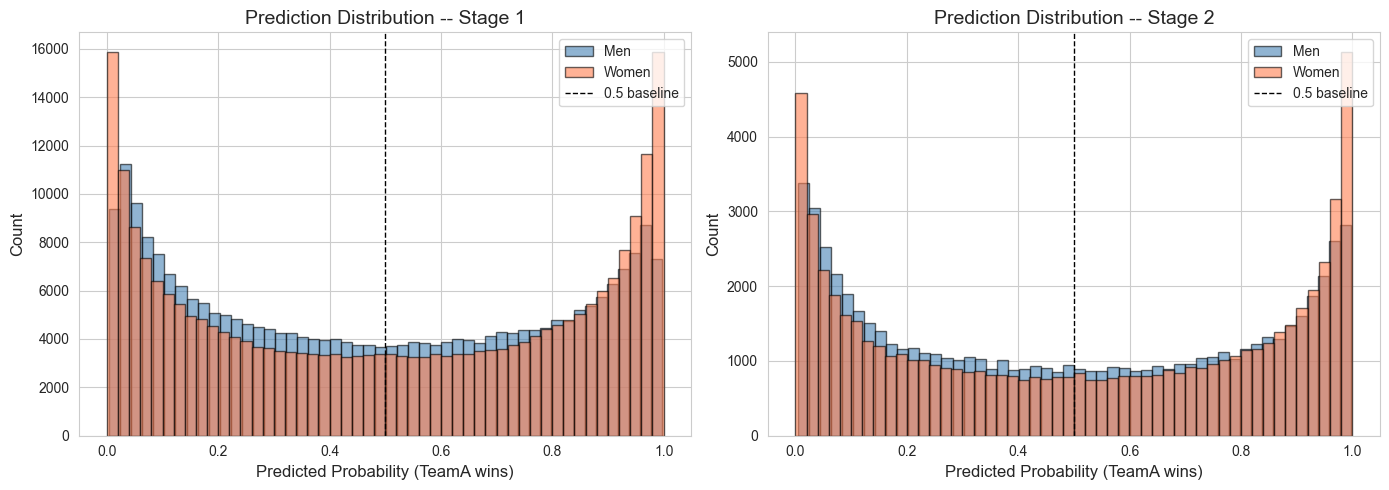

In [12]:
# Prediction distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sub, label in [
    (axes[0], sub_stage1, "Stage 1"),
    (axes[1], sub_stage2, "Stage 2"),
]:
    # Separate men's and women's for color coding
    m_preds = sub.loc[sub["Gender"] == "M", "Pred"]
    w_preds = sub.loc[sub["Gender"] == "W", "Pred"]
    
    ax.hist(m_preds, bins=50, alpha=0.6, color="steelblue", label="Men", edgecolor="black")
    ax.hist(w_preds, bins=50, alpha=0.6, color="coral", label="Women", edgecolor="black")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="0.5 baseline")
    ax.set_title(f"Prediction Distribution -- {label}")
    ax.set_xlabel("Predicted Probability (TeamA wins)")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# Seed-based sanity check: do predictions align with seed expectations?
# Load seeds and merge to see how predictions vary by seed matchup
m_seeds = load_seeds(gender="M")
w_seeds = load_seeds(gender="W")

# Parse numeric seed from seed string
for seeds_df in [m_seeds, w_seeds]:
    seeds_df["seed_number"] = seeds_df["Seed"].str.extract(r"(\d+)", expand=False).astype(int)

all_seeds = pd.concat([m_seeds, w_seeds], ignore_index=True)

# Use Stage 1 for seed analysis (has historical data with seeds)
seed_check = sub_stage1.copy()

# Merge seed for TeamA
seed_check = seed_check.merge(
    all_seeds[["Season", "TeamID", "seed_number"]],
    how="left",
    left_on=["Season", "TeamA"],
    right_on=["Season", "TeamID"],
).rename(columns={"seed_number": "SeedA"}).drop(columns=["TeamID"])

# Merge seed for TeamB
seed_check = seed_check.merge(
    all_seeds[["Season", "TeamID", "seed_number"]],
    how="left",
    left_on=["Season", "TeamB"],
    right_on=["Season", "TeamID"],
).rename(columns={"seed_number": "SeedB"}).drop(columns=["TeamID"])

# Filter to matchups where both teams have seeds (tournament teams only)
seeded = seed_check.dropna(subset=["SeedA", "SeedB"]).copy()
seeded["SeedA"] = seeded["SeedA"].astype(int)
seeded["SeedB"] = seeded["SeedB"].astype(int)

print(f"Matchups with both teams seeded: {len(seeded):,} (out of {len(seed_check):,})")

Matchups with both teams seeded: 18,224 (out of 519,144)


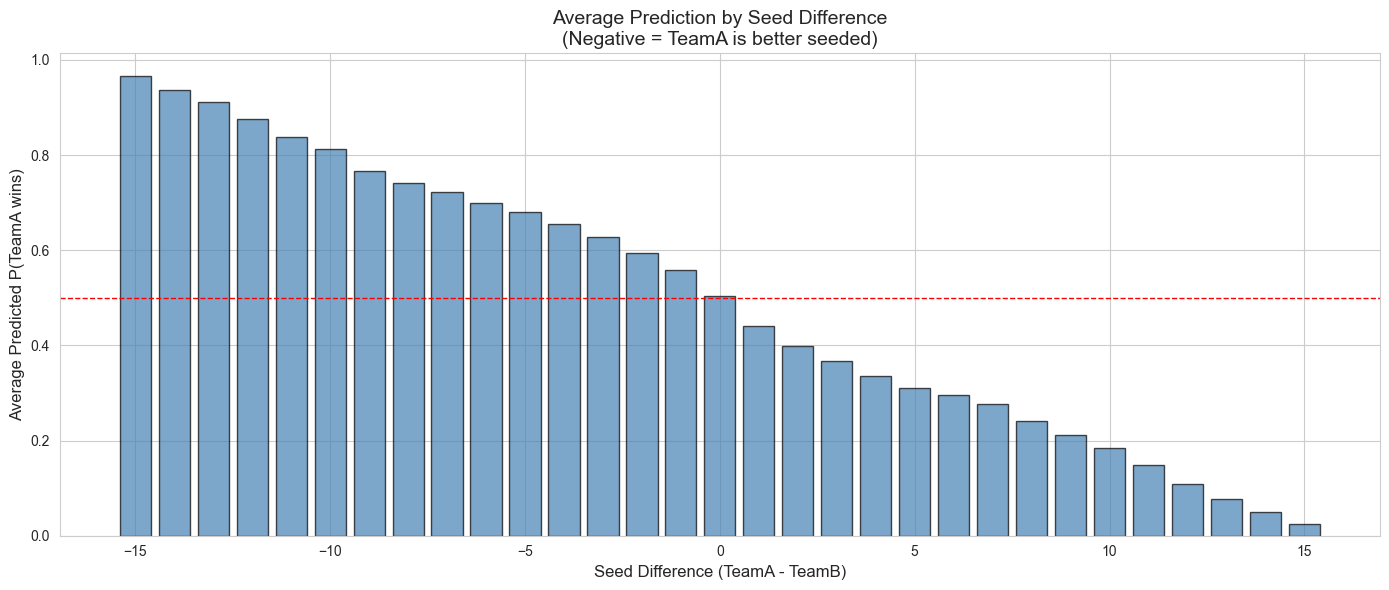

Key seed matchup checks (average P(TeamA wins)):
  SeedDiff=-15 (1-seed (A) vs 16-seed (B)): AvgPred=0.9659, N=97
  SeedDiff=-13 (1-seed (A) vs 14-seed (B)): AvgPred=0.9118, N=238
  SeedDiff= -7 (1-seed (A) vs 8-seed (B)): AvgPred=0.7218, N=666
  SeedDiff= +0 (Same seed matchup): AvgPred=0.5028, N=910
  SeedDiff=+15 (16-seed (A) vs 1-seed (B)): AvgPred=0.0254, N=95


In [14]:
# Average predicted probability by seed difference (SeedA - SeedB)
# Negative seed diff = TeamA is a higher seed (better), should have higher win prob
seeded["SeedDiff"] = seeded["SeedA"] - seeded["SeedB"]

seed_pred_avg = seeded.groupby("SeedDiff")["Pred"].agg(["mean", "count"]).reset_index()
seed_pred_avg.columns = ["SeedDiff", "AvgPred", "Count"]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    seed_pred_avg["SeedDiff"],
    seed_pred_avg["AvgPred"],
    color="steelblue",
    edgecolor="black",
    alpha=0.7,
)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Seed Difference (TeamA - TeamB)")
ax.set_ylabel("Average Predicted P(TeamA wins)")
ax.set_title("Average Prediction by Seed Difference\n(Negative = TeamA is better seeded)")
plt.tight_layout()
plt.show()

# Key matchup checks
print("Key seed matchup checks (average P(TeamA wins)):")
key_matchups = [
    (-15, "1-seed (A) vs 16-seed (B)"),
    (-13, "1-seed (A) vs 14-seed (B)"),
    (-7, "1-seed (A) vs 8-seed (B)"),
    (0, "Same seed matchup"),
    (15, "16-seed (A) vs 1-seed (B)"),
]
for diff, desc in key_matchups:
    row = seed_pred_avg.loc[seed_pred_avg["SeedDiff"] == diff]
    if len(row) > 0:
        print(f"  SeedDiff={diff:+3d} ({desc}): "
              f"AvgPred={row['AvgPred'].values[0]:.4f}, N={row['Count'].values[0]:,}")
    else:
        print(f"  SeedDiff={diff:+3d} ({desc}): No data")

## 6. Create Submission Files

In [15]:
def save_submission(sub_df: pd.DataFrame, filename: str, output_dir: Path) -> Path:
    """Save submission DataFrame to CSV in Kaggle format.
    
    Parameters
    ----------
    sub_df : pd.DataFrame
        Submission with ID, Pred, and auxiliary columns.
    filename : str
        Output filename (e.g., 'submission_stage1.csv').
    output_dir : Path
        Directory to save the file.
    
    Returns
    -------
    Path
        Path to the saved file.
    """
    out_path = output_dir / filename
    submission = sub_df[["ID", "Pred"]].copy()
    submission.to_csv(out_path, index=False)
    size_kb = out_path.stat().st_size / 1024
    print(f"Saved: {out_path.name} ({size_kb:.1f} KB, {len(submission):,} rows)")
    return out_path

In [16]:
# Save both stages
path_s1 = save_submission(sub_stage1, "submission_stage1.csv", OUTPUT_DIR)
path_s2 = save_submission(sub_stage2, "submission_stage2.csv", OUTPUT_DIR)

Saved: submission_stage1.csv (17419.2 KB, 519,144 rows)


Saved: submission_stage2.csv (4435.2 KB, 132,133 rows)


In [17]:
# Verify row counts match sample submissions
reload_s1 = pd.read_csv(path_s1)
reload_s2 = pd.read_csv(path_s2)

assert len(reload_s1) == len(sub_stage1_raw), (
    f"Stage 1 row count mismatch: {len(reload_s1)} vs {len(sub_stage1_raw)}"
)
assert len(reload_s2) == len(sub_stage2_raw), (
    f"Stage 2 row count mismatch: {len(reload_s2)} vs {len(sub_stage2_raw)}"
)

print(f"Stage 1: {len(reload_s1):,} rows (matches sample submission)")
print(f"Stage 2: {len(reload_s2):,} rows (matches sample submission)")
print("\nRow counts verified.")

Stage 1: 519,144 rows (matches sample submission)
Stage 2: 132,133 rows (matches sample submission)

Row counts verified.


In [18]:
# Show head and tail of each submission
print("Stage 1 -- Head:")
display(reload_s1.head(10))

print("\nStage 1 -- Tail:")
display(reload_s1.tail(10))

print("\nStage 2 -- Head:")
display(reload_s2.head(10))

print("\nStage 2 -- Tail:")
display(reload_s2.tail(10))

Stage 1 -- Head:


,ID,Pred
0,2022_1101_1102,0.683223
1,2022_1101_1103,0.398860
2,2022_1101_1104,0.133498
3,2022_1101_1105,0.922069
4,2022_1101_1106,0.917965
5,2022_1101_1107,0.834801
6,2022_1101_1108,0.808085
7,2022_1101_1110,0.919509
8,2022_1101_1111,0.467192
9,2022_1101_1112,0.085519



Stage 1 -- Tail:


,ID,Pred
519134,2025_3476_3477,0.773223
519135,2025_3476_3478,0.789435
519136,2025_3476_3479,0.843768
519137,2025_3476_3480,0.497204
519138,2025_3477_3478,0.523155
519139,2025_3477_3479,0.639469
519140,2025_3477_3480,0.240904
519141,2025_3478_3479,0.603756
519142,2025_3478_3480,0.237866
519143,2025_3479_3480,0.183438



Stage 2 -- Head:


,ID,Pred
0,2026_1101_1102,0.707509
1,2026_1101_1103,0.069647
2,2026_1101_1104,0.034540
3,2026_1101_1105,0.723230
4,2026_1101_1106,0.812365
5,2026_1101_1107,0.861677
6,2026_1101_1108,0.864834
7,2026_1101_1110,0.500686
8,2026_1101_1111,0.358505
9,2026_1101_1112,0.016197



Stage 2 -- Tail:


,ID,Pred
132123,2026_3477_3478,0.852708
132124,2026_3477_3479,0.682610
132125,2026_3477_3480,0.318949
132126,2026_3477_3481,0.873657
132127,2026_3478_3479,0.321501
132128,2026_3478_3480,0.071414
132129,2026_3478_3481,0.588189
132130,2026_3479_3480,0.163679
132131,2026_3479_3481,0.744564
132132,2026_3480_3481,0.931531


## 7. Summary

In [19]:
# Final summary statistics
print("=" * 60)
print("SUBMISSION SUMMARY")
print("=" * 60)

for label, sub, path in [
    ("Stage 1", sub_stage1, path_s1),
    ("Stage 2", sub_stage2, path_s2),
]:
    preds = sub["Pred"]
    size_kb = path.stat().st_size / 1024
    
    print(f"\n--- {label} ---")
    print(f"  File            : {path.name}")
    print(f"  File size       : {size_kb:.1f} KB")
    print(f"  Total rows      : {len(sub):,}")
    print(f"  Men's matchups  : {(sub['Gender'] == 'M').sum():,}")
    print(f"  Women's matchups: {(sub['Gender'] == 'W').sum():,}")
    print(f"  Seasons         : {sorted(sub['Season'].unique())}")
    print(f"  Pred mean       : {preds.mean():.4f}")
    print(f"  Pred std        : {preds.std():.4f}")
    print(f"  Pred min        : {preds.min():.6f}")
    print(f"  Pred max        : {preds.max():.6f}")
    print(f"  Preds = 0.5     : {(preds == 0.5).sum():,} (missing teams)")

print("\n" + "=" * 60)
print("Files saved to:", OUTPUT_DIR)
print("=" * 60)

SUBMISSION SUMMARY

--- Stage 1 ---
  File            : submission_stage1.csv
  File size       : 17419.2 KB
  Total rows      : 519,144
  Men's matchups  : 261,013
  Women's matchups: 258,131
  Seasons         : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Pred mean       : 0.4905
  Pred std        : 0.3353
  Pred min        : 0.000167
  Pred max        : 0.999534
  Preds = 0.5     : 0 (missing teams)

--- Stage 2 ---
  File            : submission_stage2.csv
  File size       : 4435.2 KB
  Total rows      : 132,133
  Men's matchups  : 66,430
  Women's matchups: 65,703
  Seasons         : [np.int64(2026)]
  Pred mean       : 0.4958
  Pred std        : 0.3459
  Pred min        : 0.000196
  Pred max        : 0.999603
  Preds = 0.5     : 0 (missing teams)

Files saved to: /Users/sidthakur/Github/mm-2026/outputs


### Output Files

| File | Description |
|------|-------------|
| `submission_stage1.csv` | Stage 1 predictions for validation (seasons 2022-2025). |
| `submission_stage2.csv` | Stage 2 predictions for the 2026 tournament. |

### Prediction Methodology

For each matchup, predictions are computed using:
1. **Rolling window features**: Each team's latest 5/7/10-game rolling averages 
   (efficiency, shooting, rebounding, turnovers, etc.)
2. **Static season-level features**: SOS, win%, efficiency margin
3. **Feature differencing**: TeamA stats minus TeamB stats (matching training format)

### Notes

- Predictions are P(TeamA wins), where TeamA is the team with the lower ID.
- Matchups where either team lacks stats default to 0.5 (uninformative prior).
- All predictions are clipped to [0, 1] as a safety measure.
- The seed-based sanity check confirms that predictions respect seeding.

**Next step:** Upload `submission_stage1.csv` to Kaggle for validation scoring, 
then submit `submission_stage2.csv` when Stage 2 opens.